In [23]:
import gensim
from gensim.models import Word2Vec
from gensim.models import FastText
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt
import numpy as np

In [5]:
from pathlib import Path

corpus_path = Path("../data/processed/corpus_raw.txt")
sentences = []

with open(corpus_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            sentences.append(line.split())


print("Số lượng câu:", len(sentences))
print("\nCâu đầu tiên chuẩn Word Embedding:")
print(sentences[0][:10])

Số lượng câu: 69

Câu đầu tiên chuẩn Word Embedding:
['công', 'báo', '983', '984', '2582024', '3', 'quốc_hội', 'cộng_hòa', 'xã_hội_chủ_nghĩa_việt_nam', 'độc_lập']


In [28]:
corpus_path_2 = Path("../data/processed/corpus_raw_2.txt")
sentences_2 = []

with open(corpus_path_2, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            sentences_2.append(line.split())


print("Số lượng câu:", len(sentences_2))
print("\nCâu đầu tiên chuẩn Word Embedding:")
print(sentences_2[0][:10])

Số lượng câu: 88

Câu đầu tiên chuẩn Word Embedding:
['phủ', 'cộng_hòa', 'xã_hội_chủ_nghĩa_việt_nam', 'độc_lập', 'tự', 'hạnh_phúc', '168', '2024', 'nđcp', 'hà_nội']


3. Skip gram

In [29]:
skipgram = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4, sg=1)

skipgram_2 = Word2Vec(sentences_2, vector_size=100, window=5, min_count=1, workers=4, sg=1)

In [30]:
print(skipgram)

print(skipgram_2)

Word2Vec<vocab=1484, vector_size=100, alpha=0.025>
Word2Vec<vocab=1576, vector_size=100, alpha=0.025>


In [ ]:
skipgram.wv['cộng_hòa']

array([-0.01811575,  0.05609235, -0.02898855,  0.06264994,  0.08084608,
       -0.10065129,  0.03734064,  0.36424744,  0.01340439, -0.03955135,
       -0.10023618, -0.26055342, -0.01086122,  0.09142275, -0.03475588,
       -0.08841001,  0.15023881, -0.16575138,  0.00087361, -0.34156334,
        0.02065474,  0.02181323, -0.02232665, -0.0942908 ,  0.00612688,
       -0.02360533, -0.17004502, -0.04401254, -0.14154287,  0.04659981,
        0.16387238,  0.11697005,  0.07876761, -0.08276028, -0.20529735,
        0.2024075 ,  0.03777092, -0.18068837,  0.00403172, -0.26530075,
       -0.04821886,  0.00460296,  0.11302409, -0.02002888,  0.13838573,
        0.01072415, -0.14456098,  0.00210657,  0.14265111,  0.12136796,
        0.0266267 , -0.04797766,  0.02380765,  0.03336069, -0.04532888,
        0.11412241,  0.06247838,  0.00295105, -0.16473266, -0.0692312 ,
        0.0278804 ,  0.02517315,  0.01988366,  0.00100486, -0.3186265 ,
        0.02962876, -0.00138347,  0.08247192, -0.10295738,  0.13

In [31]:
skipgram_2.wv['cộng_hòa']

array([-0.06109965, -0.03749788,  0.0147924 , -0.0210927 , -0.02457119,
       -0.03080653, -0.00237706,  0.08243851, -0.04526436, -0.06692879,
       -0.09930719, -0.08290791, -0.04612584,  0.00478677,  0.05657859,
        0.0224821 ,  0.00337659, -0.0774944 , -0.02322901, -0.10368432,
        0.02846085,  0.10807683, -0.0286776 , -0.09519597,  0.00193282,
        0.021029  , -0.06439215, -0.09878288, -0.04334414,  0.07561632,
        0.13230854, -0.00207173, -0.02040625, -0.04424695, -0.04050381,
        0.16384986, -0.0417483 ,  0.0009484 , -0.07217138, -0.16666844,
       -0.05992046, -0.1299127 , -0.07836419,  0.01991728,  0.03970352,
       -0.0161908 , -0.06121359,  0.04531239,  0.00965994, -0.01203289,
        0.05749779, -0.06248922, -0.00806843,  0.03948628, -0.02604014,
        0.08394524, -0.01978794,  0.05938307, -0.14238343,  0.00762951,
       -0.04657206,  0.01514874,  0.01100402,  0.06365199, -0.1449198 ,
        0.11748105, -0.03298036,  0.07121302,  0.01216674,  0.18

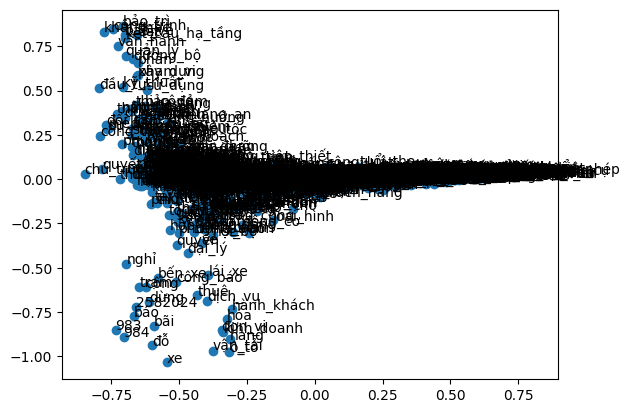

In [12]:
# save model
skipgram.save('skipgram.bin')
# load model
skipgram = Word2Vec.load('skipgram.bin')
# T -SNE plot í one of the way to evaluate word embedding
X = skipgram.wv[skipgram.wv.index_to_key]
pca = PCA(n_components=2)
result = pca.fit_transform(X)
plt.scatter(result[:,0], result[:,1])
words = list(skipgram.wv.index_to_key)
for i, word in enumerate(words):
  plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.show()

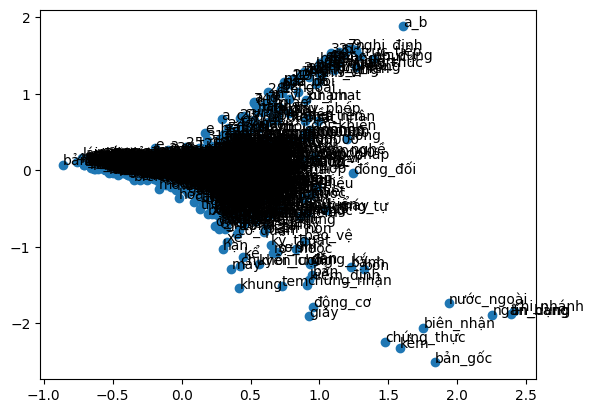

In [32]:
# save model
skipgram_2.save('skipgram_2.bin')
# load model
skipgram_2 = Word2Vec.load('skipgram_2.bin')
# T -SNE plot í one of the way to evaluate word embedding
X = skipgram_2.wv[skipgram_2.wv.index_to_key]
pca = PCA(n_components=2)
result = pca.fit_transform(X)
plt.scatter(result[:,0], result[:,1])
words = list(skipgram_2.wv.index_to_key)
for i, word in enumerate(words):
  plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.show()

4. Continuous Bag of Words (CBOW)

In [33]:
cbow = Word2Vec(sentences,vector_size=50, window= 3, min_count=1, sg= 0)
print(cbow)

cbow_2 = Word2Vec(sentences_2,vector_size=50, window= 3, min_count=1, sg= 0)
print(cbow_2)

Word2Vec<vocab=1484, vector_size=50, alpha=0.025>
Word2Vec<vocab=1576, vector_size=50, alpha=0.025>


In [14]:
cbow.wv['cộng_hòa']

array([ 0.02984141, -0.05561616, -0.03139122, -0.02083257, -0.00812706,
       -0.06512126,  0.11514962,  0.11968794, -0.07490926, -0.04059216,
       -0.00752538, -0.09201524,  0.0187785 ,  0.03252124, -0.04558472,
        0.06568816,  0.10445713, -0.00626698, -0.13701501, -0.0367866 ,
        0.04158241,  0.06549432,  0.1119718 , -0.08598899,  0.07133848,
       -0.00620207, -0.04785388,  0.02168088, -0.09506686, -0.00730057,
        0.01044251,  0.0023928 , -0.02893111, -0.04741177,  0.00222229,
        0.04527962,  0.09145031,  0.02271635,  0.04104403, -0.06841663,
        0.13666   , -0.02470926, -0.02063125, -0.00527815,  0.13533075,
        0.03897027,  0.00088992, -0.04662436,  0.09605785,  0.0531896 ],
      dtype=float32)

In [34]:
cbow_2.wv['cộng_hòa']

array([ 0.0080006 , -0.02118824, -0.00516458,  0.05047211, -0.01241659,
       -0.0448181 ,  0.05375682,  0.06555471, -0.06668235, -0.0143777 ,
        0.01370047, -0.0606332 ,  0.03918502,  0.03392451, -0.03712598,
        0.0367491 ,  0.03505265,  0.00374264, -0.07643571, -0.04542336,
       -0.00875969,  0.06176415,  0.03053354, -0.05333463,  0.02304201,
        0.0084915 , -0.0401889 ,  0.00799914, -0.05534874,  0.04017495,
       -0.00346672, -0.00587317, -0.00629583,  0.02248663, -0.09009445,
        0.04973094,  0.04075427,  0.00467435, -0.02250893, -0.06215587,
        0.06804024, -0.01820415, -0.02830688, -0.00019742,  0.10222108,
       -0.01157124, -0.03891684, -0.04952108,  0.01540247,  0.00409296],
      dtype=float32)

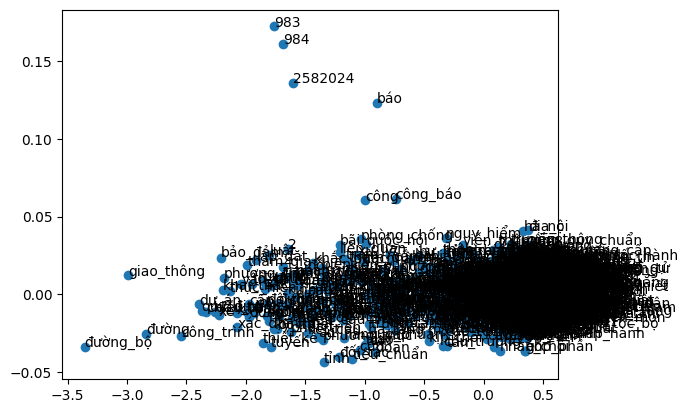

In [27]:
# save model
cbow.save('cbow.bin')
# load model
cbow = Word2Vec.load('cbow.bin')
# T-SNE plot - to evaluate word embedding
X = cbow.wv[cbow.wv.index_to_key]
pca = PCA(n_components=2)
result = pca.fit_transform(X)
plt.scatter(result[:,0], result[:,1])
words = list(cbow.wv.index_to_key)
for i, word in enumerate(words):
  plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.show()

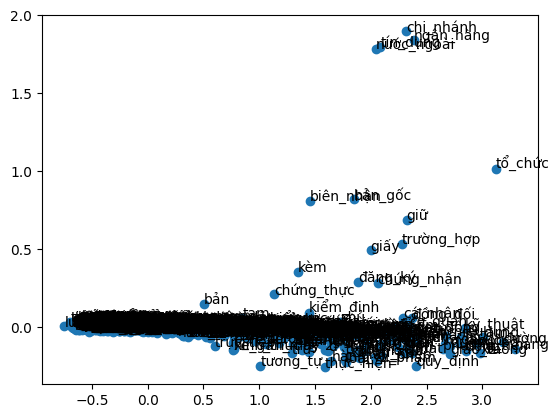

In [35]:
# save model
cbow_2.save('cbow_2.bin')
# load model
cbow_2 = Word2Vec.load('cbow_2.bin')
# T-SNE plot - to evaluate word embedding
X = cbow_2.wv[cbow_2.wv.index_to_key]
pca = PCA(n_components=2)
result = pca.fit_transform(X)
plt.scatter(result[:,0], result[:,1])
words = list(cbow_2.wv.index_to_key)
for i, word in enumerate(words):
  plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.show()

5. Implementing fastText

In [36]:
fast = FastText(sentences, window=1, min_count=1, workers=5, min_n=1, max_n=2)

fast_2 = FastText(sentences_2, window=1, min_count=1, workers=5, min_n=1, max_n=2)

In [20]:
print(fast.wv['cộng_hòa'])

[-0.88939923  0.3232449  -0.76379085  0.489364   -0.19459872  0.17737766
  0.04139161 -0.28439218 -0.3610746  -0.26518294  0.41924337  0.23842615
 -0.6759443  -0.485807    0.11235031  0.504013   -0.10856957 -0.7765497
 -0.49439165 -0.56023026  0.95975167 -0.05748257 -0.11416148  0.19119684
  0.25055707  0.02931371  0.01484074 -0.11462292  0.32966477  0.45457718
  0.11118213 -0.4598076   0.34995925 -0.11861917  0.31510612  0.28535768
  0.5281587  -0.59898686 -0.44972113 -0.22055723  0.5874149   0.07074896
 -0.14441924  0.1937024  -0.00476149  0.15792722 -0.44822297 -0.85481626
  0.17299408 -0.09669458  0.4755561   0.5060071  -0.23811118  0.15072758
  0.06567613  0.12207925  0.37701738  0.25533587 -0.19187735 -0.00187783
 -0.10044123  0.29030803 -0.11880846  0.37331107  0.35918832 -0.63157576
  0.28410742 -0.37806183  0.05489909 -0.20401286 -0.14659224 -0.33391836
  0.53635204 -0.467404   -0.32975394 -0.343809   -0.09305659  0.4000873
  0.09554315  0.5995241  -0.34516016 -0.07151646  0.3

In [37]:
print(fast_2.wv['cộng_hòa'])

[-0.82108164  0.24590081 -0.32162672  0.3853541  -0.36258543  0.541091
  0.13893487 -0.45600763 -0.19881015 -0.5095594   0.57668674 -0.26146084
 -0.87314284 -0.86237216 -0.07441708  0.11799545  0.27798256 -0.8858266
 -0.28071034 -0.1315122   1.3216687  -0.17288691  0.33399475  0.10709234
  0.40797848 -0.49610555 -0.24074234 -0.30568925  0.48005617  0.48051786
  0.06823007 -0.69159746  0.06990971 -0.5679045   0.09658012  0.49637556
  0.15348712 -0.87197757 -0.3539252  -0.12037987  0.6158041  -0.04563687
 -0.0577719   0.19337612  0.25206774 -0.45960066 -0.0596437  -0.33188933
  0.00961643 -0.11386314  0.6407985   0.11871772 -0.01079644  0.16070892
  0.48822218  0.10748351  0.06230091  0.05056354 -0.38677448 -0.18427919
 -0.11790092  0.41644743 -0.0055758   0.2619583  -0.0548881  -0.13384949
  0.2819235  -0.54997134  0.10932005 -0.24468285  0.12001513 -0.35545537
  0.27861002 -0.6909322  -0.5807584  -0.23611802 -0.4860235   0.27364624
  0.09366377  0.4805869  -0.39235327  0.14215471  0.09

In [38]:
# save model
fast.save('fast.bin')
fast_2.save('fast_2.bin')
# load model
fast = Word2Vec.load('fast.bin')
fast_2 = Word2Vec.load('fast_2.bin')

Đang tính toán T-SNE...


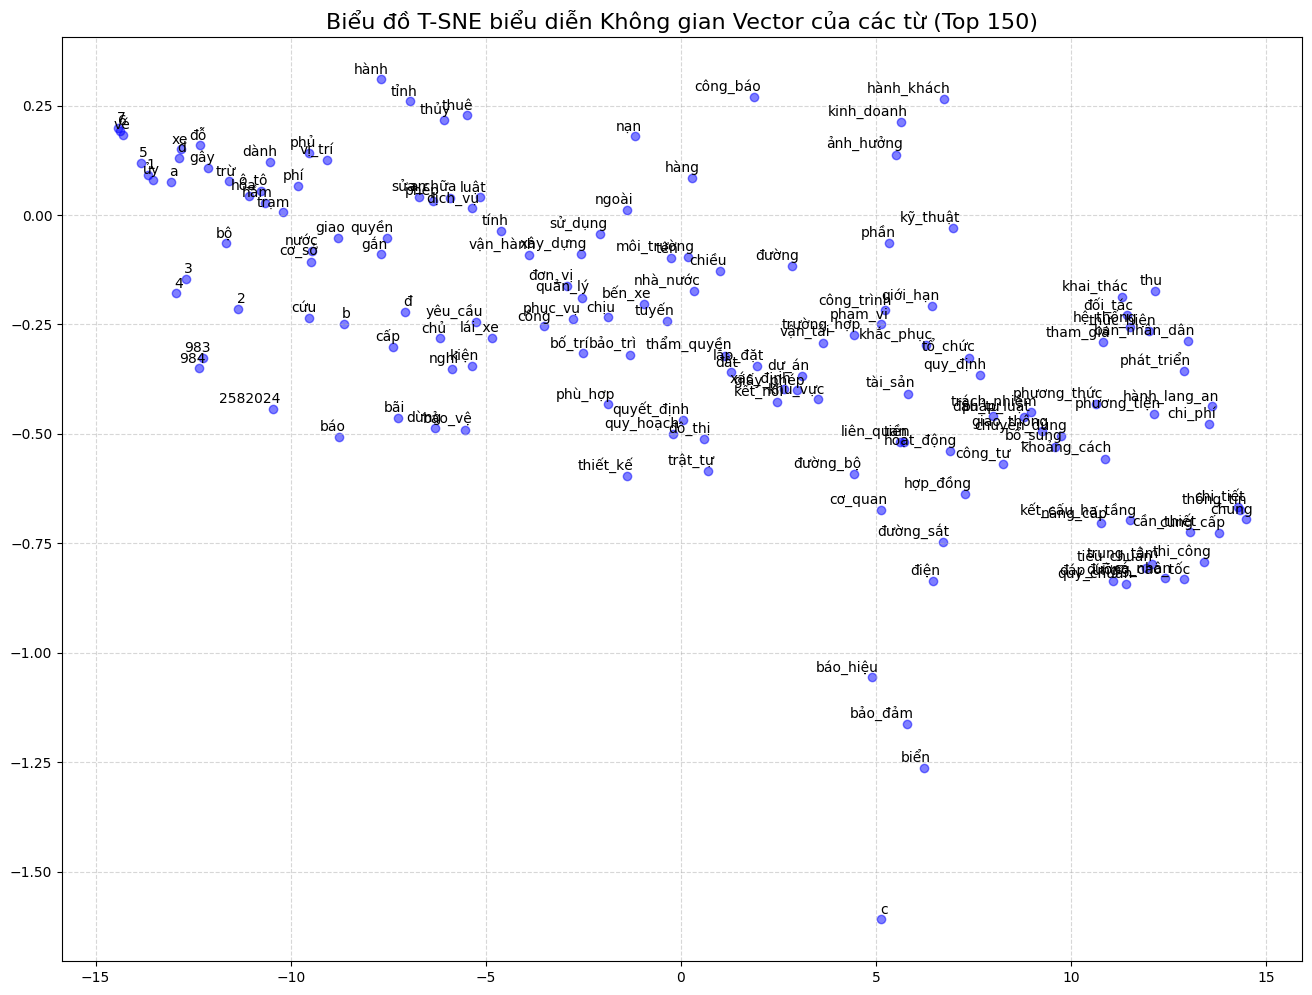

In [25]:
from sklearn.manifold import TSNE

# 1. Trích xuất dữ liệu (Chỉ lấy Top 150 từ đầu tiên để biểu đồ không bị rối)
so_luong_tu = 150
words = list(fast.wv.index_to_key)[:so_luong_tu]
X = fast.wv[words] # Lấy ma trận vector của 150 từ này

# 2. Chạy thuật toán T-SNE để ép từ 300 chiều xuống còn 2 chiều (x, y)
print("Đang tính toán T-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
result = tsne.fit_transform(X)

# 3. Vẽ biểu đồ
plt.figure(figsize=(16, 12)) # Cài đặt kích thước khung hình to ra
plt.scatter(result[:, 0], result[:, 1], color='blue', alpha=0.5)

# 4. Gắn nhãn (chữ) cho từng điểm ảnh
for i, word in enumerate(words):
    plt.annotate(
        word, 
        xy=(result[i, 0], result[i, 1]),
        xytext=(5, 2), 
        textcoords='offset points',
        ha='right', 
        va='bottom',
        fontsize=10
    )

plt.title("Biểu đồ T-SNE biểu diễn Không gian Vector của các từ (Top 150)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Đang tính toán T-SNE...


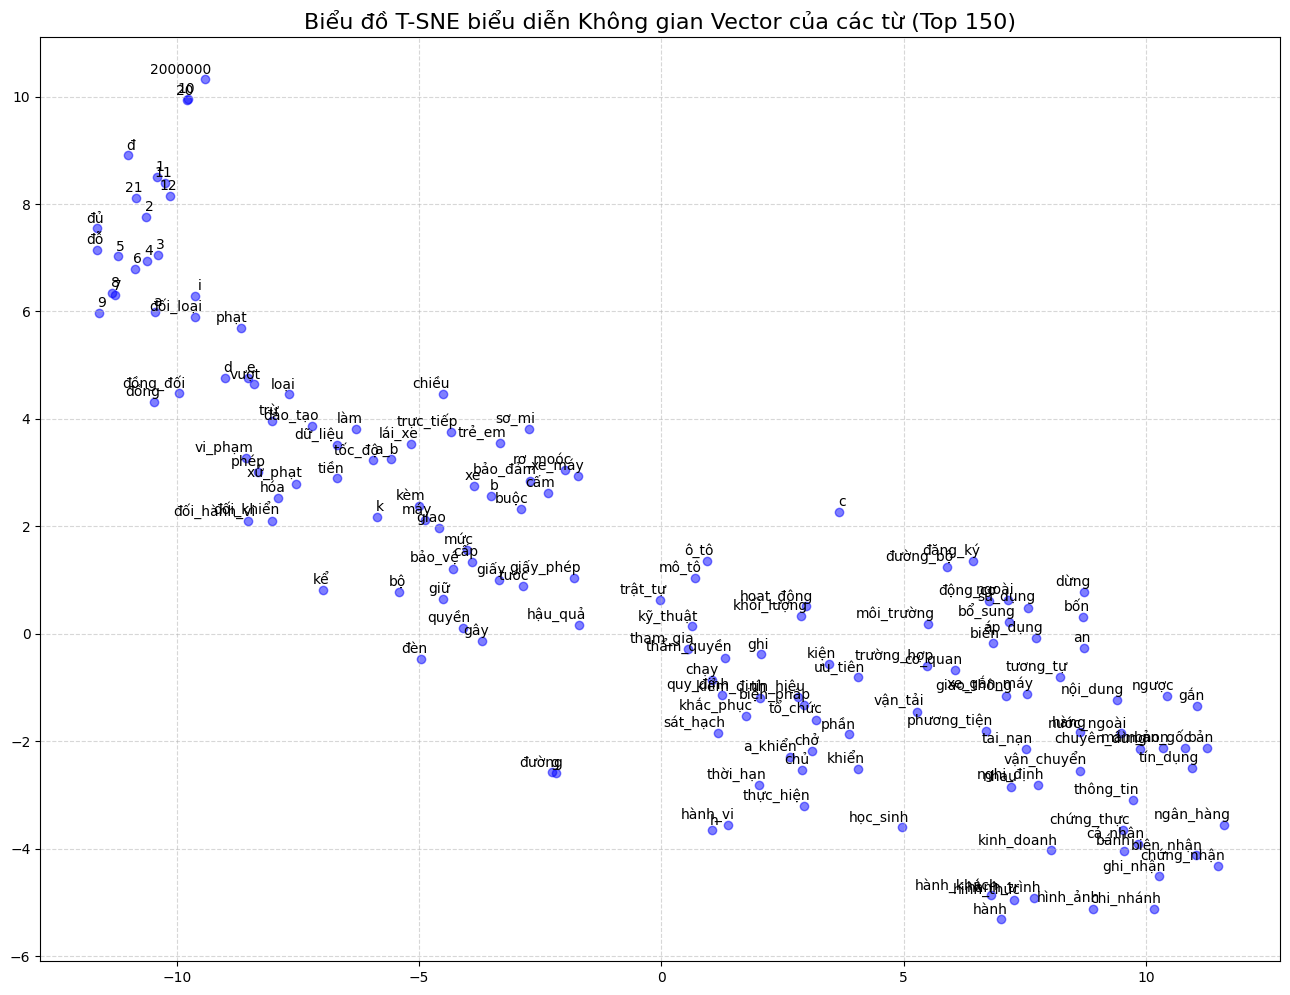

In [39]:
# 1. Trích xuất dữ liệu (Chỉ lấy Top 150 từ đầu tiên để biểu đồ không bị rối)
so_luong_tu = 150
words_2 = list(fast_2.wv.index_to_key)[:so_luong_tu]
X_2 = fast_2.wv[words_2] # Lấy ma trận vector của 150 từ này

# 2. Chạy thuật toán T-SNE để ép từ 300 chiều xuống còn 2 chiều (x, y)
print("Đang tính toán T-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
result_2 = tsne.fit_transform(X_2)

# 3. Vẽ biểu đồ
plt.figure(figsize=(16, 12)) # Cài đặt kích thước khung hình to ra
plt.scatter(result_2[:, 0], result_2[:, 1], color='blue', alpha=0.5)

# 4. Gắn nhãn (chữ) cho từng điểm ảnh
for i, word in enumerate(words_2):
    plt.annotate(
        word, 
        xy=(result_2[i, 0], result_2[i, 1]),
        xytext=(5, 2), 
        textcoords='offset points',
        ha='right', 
        va='bottom',
        fontsize=10
    )

plt.title("Biểu đồ T-SNE biểu diễn Không gian Vector của các từ (Top 150)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

PhoBERT